In [133]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree

In [134]:
dataset = pd.read_csv(r'D:\HopeAI\Training\Week9-ML and Data Science Capstone\1. Data Collection\bmw_global_sales_2018_2025.csv')
dataset

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


In [135]:
dataset.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [136]:
dataset = dataset.sort_values(by=['Region', 'Model', 'Year', 'Month'])

dataset['Sales_Change'] = dataset.groupby(['Region','Model'])['Units_Sold'].pct_change()

# Create lag features, Get last 3 months data
dataset['lag_1'] = dataset.groupby(['Region', 'Model'])['Units_Sold'].shift(1)
dataset['lag_2'] = dataset.groupby(['Region', 'Model'])['Units_Sold'].shift(2)
dataset['lag_3'] = dataset.groupby(['Region', 'Model'])['Units_Sold'].shift(3)

# Drop NA
dataset = dataset.dropna()


#Remove high importance columns
dataset = dataset.drop(columns=['Revenue_EUR'])

# Encoding
dataset = pd.get_dummies(dataset, columns=['Region', 'Model'], drop_first=True)


In [137]:
dataset.columns

Index(['Year', 'Month', 'Units_Sold', 'Avg_Price_EUR', 'BEV_Share',
       'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index', 'Sales_Change',
       'lag_1', 'lag_2', 'lag_3', 'Region_Europe', 'Region_RestOfWorld',
       'Region_USA', 'Model_5 Series', 'Model_MINI', 'Model_X3', 'Model_X5',
       'Model_X7', 'Model_i4', 'Model_iX'],
      dtype='object')

In [138]:
#Get the numerical columns
#dataset = dataset.sort_values(by=['Year', 'Month']).reset_index(drop=True)

X_Indep = dataset.drop(columns=['Sales_Change', 'Units_Sold'])
Y_Dep = dataset['Sales_Change']


In [139]:
#Split
#X_Train, X_Test, y_train, y_test = train_test_split(X_Indep, Y_Dep, test_size=1/3, random_state=0)

#Time Based Split

dataset = dataset.sort_values(by=['Year','Month']).reset_index(drop=True)

train_size = int(len(dataset) * 0.8)
X_Train = X_Indep.iloc[:train_size]
X_Test = X_Indep.iloc[train_size:]

y_train = Y_Dep.iloc[:train_size]
y_test = Y_Dep.iloc[train_size:]


In [140]:
#Random Forest
rfr = RandomForestRegressor(n_estimators=200, random_state=42)
rfr = RandomForestRegressor(n_estimators=200, random_state=42)
rfr.fit(X_Train, y_train)

#Gradient Boosting Regressor
# from sklearn.ensemble import GradientBoostingRegressor

# rfr = GradientBoostingRegressor(n_estimators=300, max_depth=5)
# rfr.fit(X_Train, y_train)


#XBoost

# from xgboost import XGBRegressor
# rfr = XGBRegressor(
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.05)
# rfr = rfr.fit(X_Train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [141]:
#check feature importance
pd.Series(rfr.feature_importances_, index=X_Train.columns).sort_values(ascending=False)

lag_1                 0.632381
GDP_Growth            0.049050
lag_3                 0.047963
BEV_Share             0.047219
Avg_Price_EUR         0.047021
lag_2                 0.044470
Premium_Share         0.040757
Fuel_Price_Index      0.031938
Month                 0.026335
Year                  0.007398
Region_Europe         0.004236
Model_iX              0.003437
Model_5 Series        0.003434
Model_X3              0.002925
Model_i4              0.002694
Region_USA            0.002644
Model_X5              0.002353
Region_RestOfWorld    0.001517
Model_X7              0.001304
Model_MINI            0.000925
dtype: float64

In [131]:
y_pred = rfr.predict(X_Test)
y_pred

array([ 6.11093115e-01,  6.13449879e-01,  6.15540100e-01,  3.38598714e-01,
        4.44665346e-01, -2.69939996e-01,  3.98001955e-01,  2.85815901e-01,
       -9.36239223e-02,  3.99230347e-01,  2.20477323e-01,  2.04099510e-01,
        5.02377951e-01,  1.56095080e-01,  4.53919717e-01,  6.93381529e-01,
        6.17521298e-01,  5.32043111e-02,  3.40828259e-01,  5.29034549e-01,
        6.92922777e-02,  6.24976083e-02,  2.32542063e-01,  2.78235834e-01,
        9.20616403e-01,  3.82176373e-01,  1.97598526e-01,  5.56543915e-02,
        9.90542066e-01,  1.81848357e-01,  4.82446906e-01,  1.29054814e+00,
        4.89411943e-02,  4.25331387e-02,  4.51890139e-01,  6.82114849e-02,
        5.19463838e-01,  1.73573340e-01,  4.12066022e-01,  9.77815660e-01,
        2.12713101e-01,  3.09061081e-01,  4.40677542e-01,  5.09248392e-01,
        3.88211716e-01,  8.15895920e-01,  3.21421255e-01,  3.58454135e-01,
        3.96197576e-01,  1.36712949e-01,  7.59949779e-01,  1.24193172e+00,
        2.90252500e-01,  

In [132]:
#Accuracy check
r2 = r2_score(y_test,y_pred)
print(r2)

-0.12214963877356833


In [117]:
rfr.feature_importances_

array([0.00739765, 0.02633497, 0.0470209 , 0.04721948, 0.04075698,
       0.04905028, 0.0319383 , 0.6323807 , 0.04446978, 0.04796262,
       0.00423627, 0.0015166 , 0.00264379, 0.00343353, 0.00092528,
       0.00292524, 0.00235316, 0.00130381, 0.00269404, 0.00343663])

In [118]:
rfr.max_features

'auto'

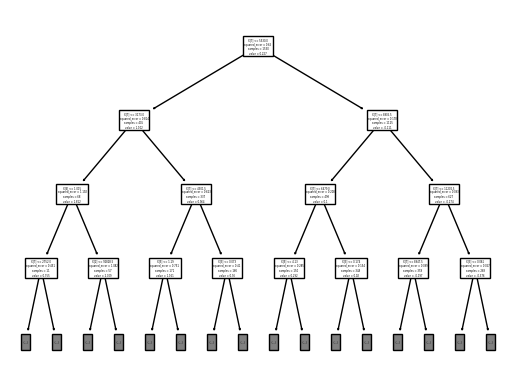

In [119]:
tree.plot_tree(rfr.estimators_[0], max_depth=3)
plt.show()